# 1. Import Libraries & Dataset

In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [2]:
# Set path for dataset
path = '/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/02 Data/Prepared Data/'

In [3]:
# Import Scaled Weather Data
df_weather = pd.read_csv(os.path.join(path, "Dataset-scaled.csv"))

In [5]:
# Check Import
df_weather.head()

,id,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,...,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,0,19600101,-1.599964,0.660514,-0.02793,0.826097,-0.001949,-1.101066,-0.265148,-0.179228,...,-0.443701,0.761754,-1.299744,-0.806427,-0.088407,-0.024706,0.372147,-0.668215,-0.519743,-0.752237
1,1,19600102,-1.599964,0.244897,-0.02793,0.735760,-0.001949,-1.058108,1.658760,-0.179228,...,0.783085,1.183580,-1.262455,-1.042055,0.503361,-0.024706,-0.829285,-0.548046,-0.629054,-0.407141
2,2,19600103,-1.599964,1.076130,-0.02793,1.277781,-0.001949,-1.251420,0.155707,-0.179228,...,0.783085,1.183580,-0.432779,-1.136306,-0.396127,-0.024706,-1.009500,-0.067372,0.054135,-0.177078
3,3,19600104,-1.599964,-1.001953,-0.02793,1.458455,-0.001949,-0.821838,-0.445514,-0.179228,...,0.783085,0.480538,0.387574,-1.183432,0.669056,-0.024706,-1.039536,-0.998679,-0.164486,-0.838511
4,4,19600105,-1.599964,0.244897,-0.02793,1.729466,-0.001949,-0.746661,-0.164944,-0.179228,...,-1.670486,-0.363113,1.729970,-0.794645,-0.490810,-0.024706,0.672505,-1.509396,-1.339569,-1.471186


In [6]:
# Import Pleasant Weather Answer Key
df_answer = pd.read_csv(os.path.join(path, "Dataset-Weather_Prediction_Pleasant_Weather.csv"))

In [7]:
# Check import
df_answer.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# 2. Data Wrangling

## Reducing dataset down to 1 year - chosen year 2010

In [9]:
df2010 = df_weather[df_weather['DATE'].astype(str).str.contains('2010')]
df2010

,id,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,...,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
731,731,19620101,-1.599964,1.076130,-0.02793,1.910140,-0.001949,-1.251420,5.165884,-0.179228,...,-2.897272,-0.081896,0.583340,-0.747520,-0.490810,-0.024706,0.732577,-2.530829,-2.705946,-1.988830
732,732,19620102,-1.599964,1.076130,-0.02793,2.000476,-0.001949,-1.251420,-0.245107,20.257548,...,-3.510664,-0.363113,1.142672,-0.653268,-0.490810,-0.024706,0.882756,-3.311925,-3.525772,-2.650263
733,733,19620103,-1.599964,1.076130,-0.02793,2.090813,-0.001949,-1.251420,-0.205026,19.260632,...,-1.670486,-0.081896,1.273183,-1.018492,-0.490810,-0.024706,-0.408784,-3.161715,-3.553099,-2.333925
734,734,19620104,-1.599964,0.244897,-0.02793,1.819803,-0.001949,-1.251420,-0.445514,17.765258,...,-1.057093,-0.081896,1.282505,-0.782864,-0.490810,-0.024706,-0.048354,-2.320534,-3.088531,-1.643734
735,735,19620105,-1.599964,1.076130,-0.02793,2.181150,-0.001949,-1.251420,-0.445514,16.768342,...,1.396477,0.199321,0.592662,-1.183432,-0.052901,-0.024706,-1.039536,-1.929986,-2.760601,-0.752237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22650,22650,20220105,-1.599964,-0.586336,-0.02793,-0.257946,-0.766151,-0.875535,-0.405433,-0.179228,...,-0.443701,-0.081896,-0.003958,-0.005290,-0.005560,-0.024706,-0.018319,-0.007287,-0.000520,-0.004530
22651,22651,20220106,-1.599964,0.660514,-0.02793,0.826097,0.563561,-1.090326,-0.425473,-0.179228,...,-0.443701,-0.081896,-0.003958,-0.005290,-0.005560,-0.024706,-0.018319,-0.007287,-0.000520,-0.004530
22652,22652,20220107,-1.599964,0.660514,-0.02793,1.006770,0.441289,-1.186982,-0.044700,-0.179228,...,-0.443701,-0.081896,-0.003958,-0.005290,-0.005560,-0.024706,-0.018319,-0.007287,-0.000520,-0.004530
22653,22653,20220108,-1.599964,0.244897,-0.02793,-0.619294,-0.766151,-1.079587,0.376155,-0.179228,...,-0.443701,-0.081896,-0.003958,-0.005290,-0.005560,-0.024706,-0.018319,-0.007287,-0.000520,-0.004530


# 3. Dendrograms

## 3.1 Single Method for Madrid & Stockholm

In [13]:
# Define cities and variables
cities = ["MADRID", "STOCKHOLM"]

variables = [
    "cloud_cover",
    "pressure",
    "global_radiation",
    "precipitation",
    "sunshine",
    "temp_mean",
    "temp_min",
    "temp_max"
]

### Note: wind speed & humidity variables were not included as they were missing from the Stockholm dataset.

In [14]:
feature_cols = [f"{city}_{var}" for city in cities for var in variables]

feature_cols

['MADRID_cloud_cover',
 'MADRID_pressure',
 'MADRID_global_radiation',
 'MADRID_precipitation',
 'MADRID_sunshine',
 'MADRID_temp_mean',
 'MADRID_temp_min',
 'MADRID_temp_max',
 'STOCKHOLM_cloud_cover',
 'STOCKHOLM_pressure',
 'STOCKHOLM_global_radiation',
 'STOCKHOLM_precipitation',
 'STOCKHOLM_sunshine',
 'STOCKHOLM_temp_mean',
 'STOCKHOLM_temp_min',
 'STOCKHOLM_temp_max']

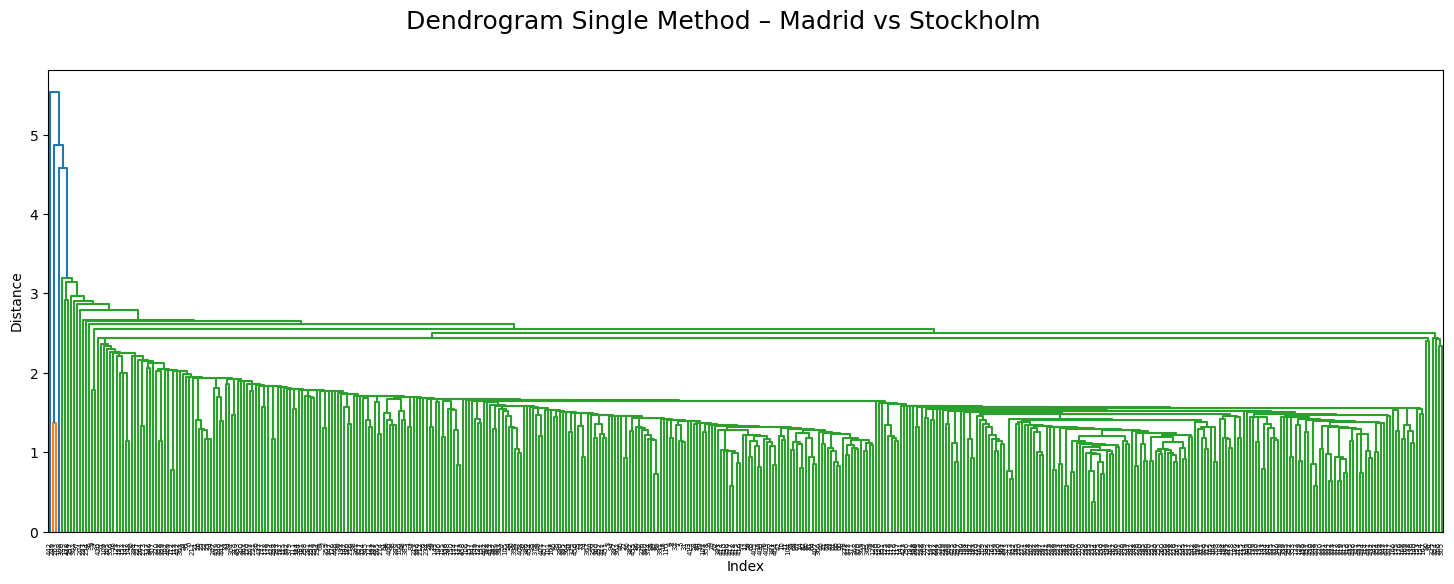

In [15]:
# Build single method dendrograms
distance_single = linkage(
    df2010.loc[:, feature_cols],
    method="single"
)

plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel("Index")
plt.ylabel("Distance")
plt.suptitle(
    "Dendrogram Single Method – Madrid vs Stockholm",
    fontsize=18
)
# Export plot
save_path = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/single_dendro_mad_sth.png"
plt.savefig(save_path, dpi=300)
plt.show()


**Single Method Dendrogram – Madrid vs Stockholm, 2010**

The single-method dendrogram shows a pronounced chaining effect, with observations merging gradually at low distance thresholds rather than forming well-separated clusters. This pattern indicates that nearest-neighbor relationships dominate the clustering process. As a result, no clear cut point emerges to suggest a natural number of clusters, and daily weather observations from Madrid and Stockholm appear interwoven rather than distinctly separated. This behavior is characteristic of single-method clustering and suggests that this method is not well suited for identifying coherent weather patterns in the ClimateWins dataset.

## 3.2 Complete Method for Madrid & Stockholm

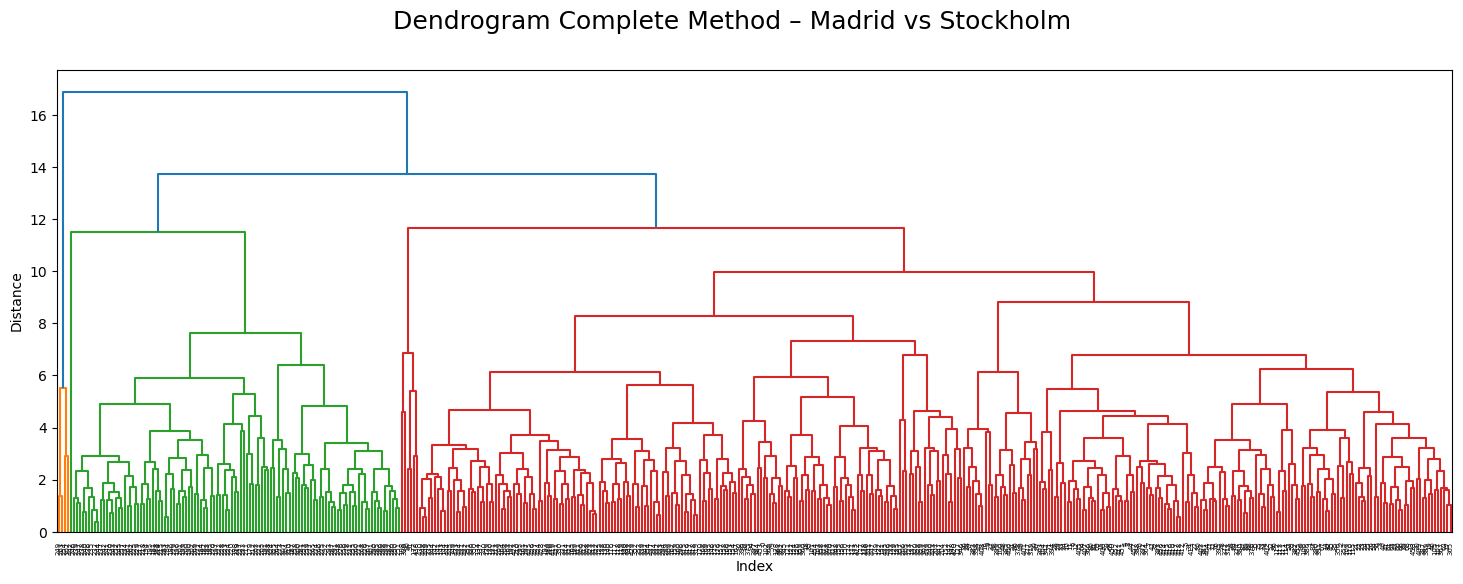

In [17]:
distance_complete = linkage(
    df2010.loc[:, feature_cols],
    method="complete"
)

plt.figure(figsize=(18, 6))
dendrogram(distance_complete, leaf_rotation=90)
plt.xlabel("Index")
plt.ylabel("Distance")
plt.suptitle("Dendrogram Complete Method – Madrid vs Stockholm", fontsize=18)

# Export plot
save_path = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/complete_dendro_mad_sth.png"
plt.savefig(save_path, dpi=300)

plt.show()


**Complete Method Dendrogram – Madrid vs Stockholm, 2010**

The complete-method dendrogram shows clearer separation and more compact clusters than the single-method. Large vertical gaps in linkage distance indicate meaningful distinctions between groups of daily weather observations, which suggests the presence of coherent weather patterns. The clusters and reveals structural differences in weather patterns between Madrid and Stockholm, likely reflecting underlying seasonal and climatic differences.

## 3.3 Average Method for Madrid & Stockholm

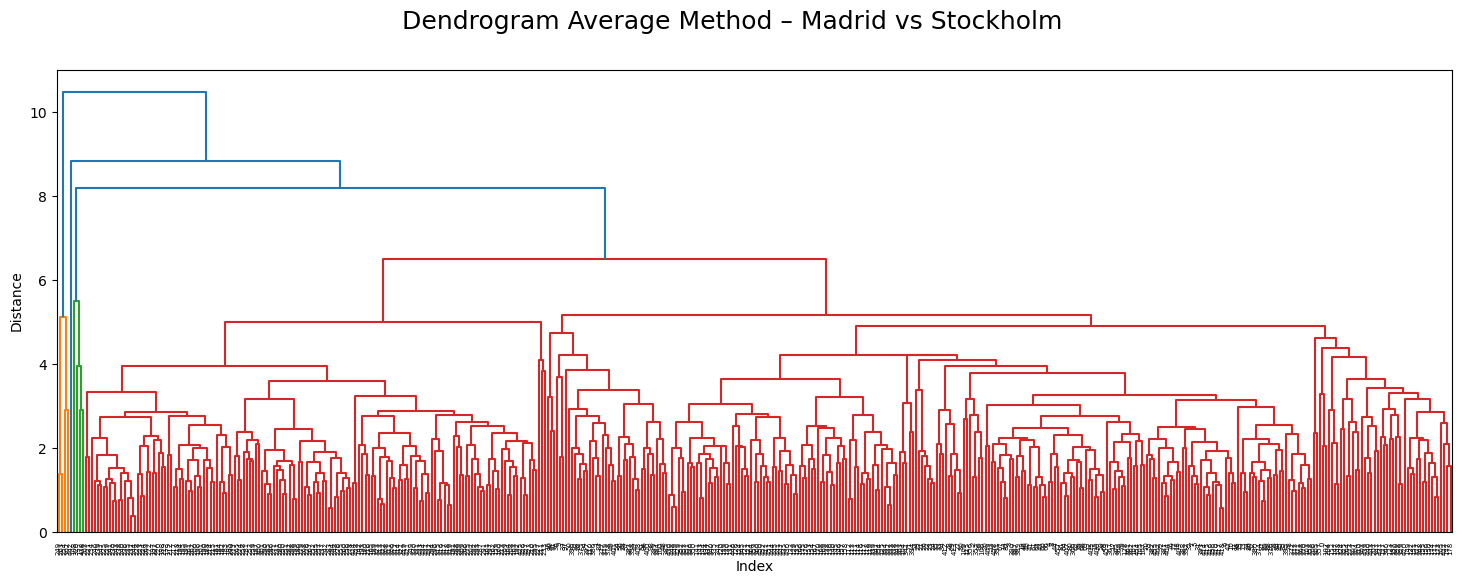

In [19]:
distance_average = linkage(
    df2010.loc[:, feature_cols],
    method="average"
)

plt.figure(figsize=(18, 6))
dendrogram(distance_average, leaf_rotation=90)
plt.xlabel("Index")
plt.ylabel("Distance")
plt.suptitle("Dendrogram Average Method – Madrid vs Stockholm", fontsize=18)
# Export plot
save_path = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/average_dendro_mad_sth.png"
plt.savefig(save_path, dpi=300)
plt.show()


**Average Method Dendrogram – Madrid vs Stockholm, 2010**

The average-method dendrogram displays a balanced clustering structure that reduces the chaining effect observed in single linkage while avoiding the overly rigid separation produced by complete linkage. Clusters merge more gradually and this pattern likely reflects seasonal transitions and partial overlap in weather conditions between Madrid and Stockholm. The average method appears to capture both shared and distinct climatic characteristics within the dataset.

# 3.4 Ward Method for Madrid & Stockholm

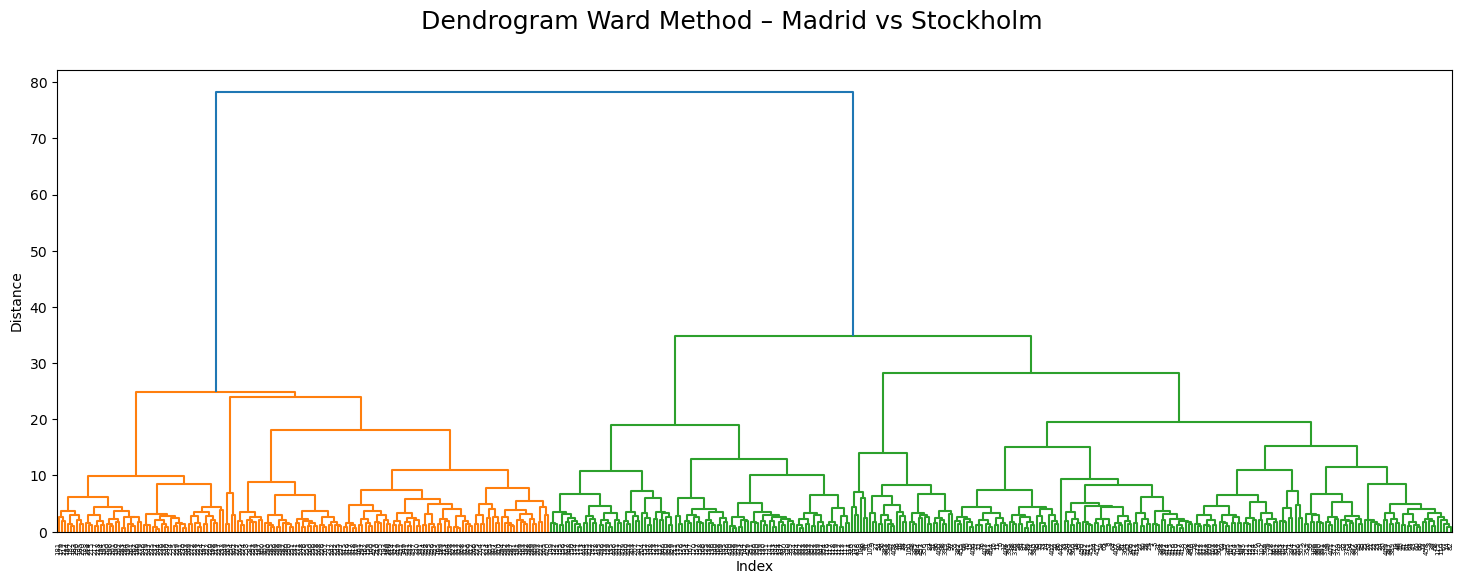

In [20]:
distance_ward = linkage(
    df2010.loc[:, feature_cols],
    method="ward"
)

plt.figure(figsize=(18, 6))
dendrogram(distance_ward, leaf_rotation=90)
plt.xlabel("Index")
plt.ylabel("Distance")
plt.suptitle("Dendrogram Ward Method – Madrid vs Stockholm", fontsize=18)
# Export plot
save_path = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/ward_dendro_mad_sth.png"
plt.savefig(save_path, dpi=300)
plt.show()

**Ward Method Dendrogram – Madrid vs Stockholm, 2010**

The Ward-method dendrogram shows the clearest high-level separation among the four linkage methods. A large jump in linkage distance at the final merge indicates that the daily observations naturally partition into two distinct macro-clusters, which suggests strongly differentiated weather regimes within the 2010 data. Compared to single, complete, and average methods, Ward produces more compact and interpretable cluster structure because it minimizes within-cluster variance. This makes Ward linkage the strongest candidate for downstream validation against ClimateWins’ “pleasant weather” labels.

# 4. Dendrogram for All Cities

In [22]:
# Define cities & variables
stations = [
    "BASEL","BELGRADE","BUDAPEST","DEBILT","DUSSELDORF","GDANSK","HEATHROW",
    "KASSEL","LJUBLJANA","MAASTRICHT","MADRID","MUNCHENB","OSLO","ROMA",
    "SONNBLICK","STOCKHOLM","TOURS","VALENTIA"
]

variables = [
    "cloud_cover","pressure","global_radiation",
    "precipitation","snow_depth","sunshine","temp_mean","temp_min","temp_max"
]

In [23]:
# Build candidate column names
candidate_cols = [f"{st}_{v}" for st in stations for v in variables]

# Keep only columns that exist in df2010
feature_cols_all = [c for c in candidate_cols if c in df2010.columns]

print("Number of selected feature columns:", len(feature_cols_all))

Number of selected feature columns: 140


## 4.1 Single method for all cities

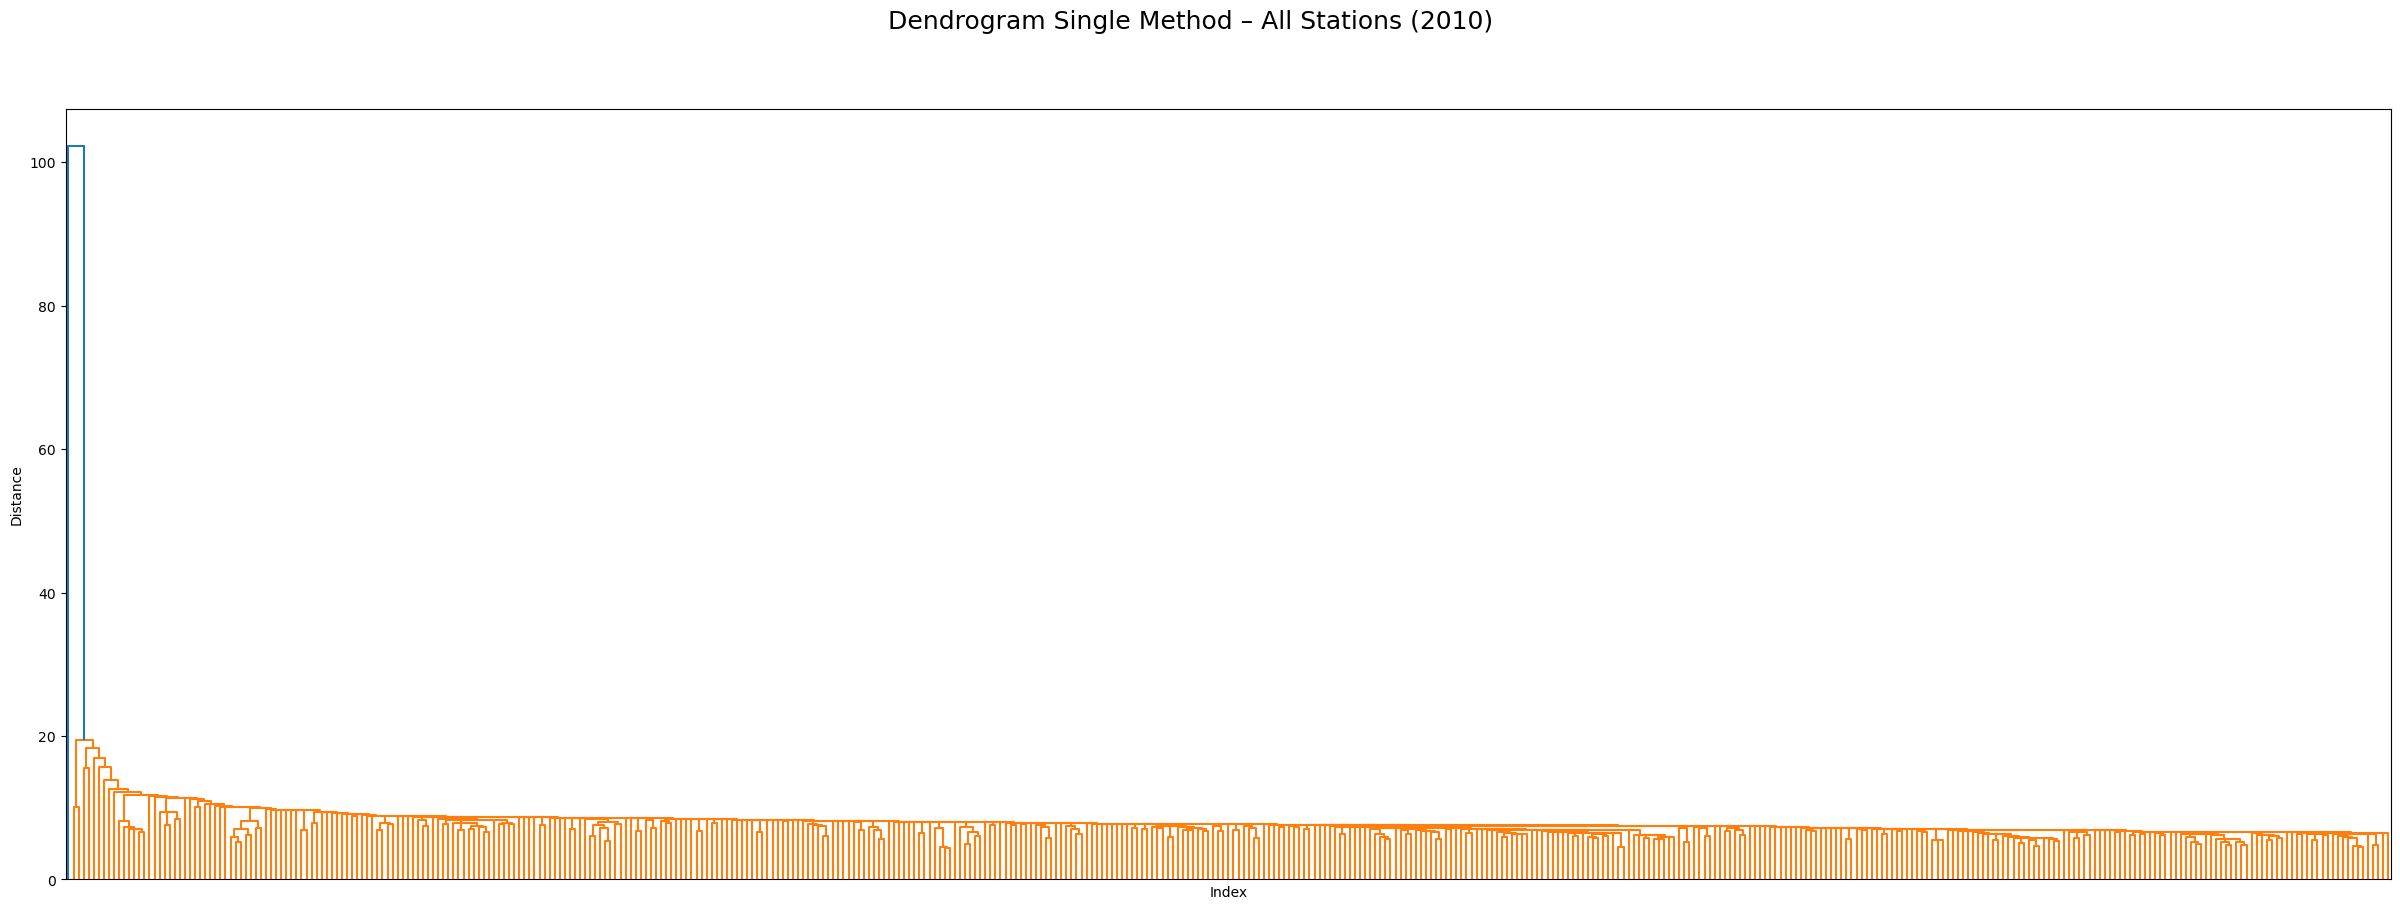

In [24]:
# Single method dendrogram for all cities
distance_single_all = linkage(df2010.loc[:, feature_cols_all], method="single")

plt.figure(figsize=(30, 10))
dendrogram(distance_single_all, leaf_rotation=90, no_labels=True)
plt.xlabel("Index")
plt.ylabel("Distance")
plt.suptitle("Dendrogram Single Method – All Stations (2010)", fontsize=18)
# Export plot
save_path = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/single_dendro_all_cities.png"
plt.savefig(save_path, dpi=300)
plt.show()

**Single Method Dendrogram – All Stations, 2010**

The single-method dendrogram shows most observations merge progressively at very low distances, producing a dense “comb” structure rather than distinct, compact clusters. The method does not reveal clear, well-separated subgroups. Overall, this pattern suggests that single linkage is not well suited for identifying interpretable weather regimes across all stations in the ClimateWins dataset.

# 4.2 Complete method for all cities

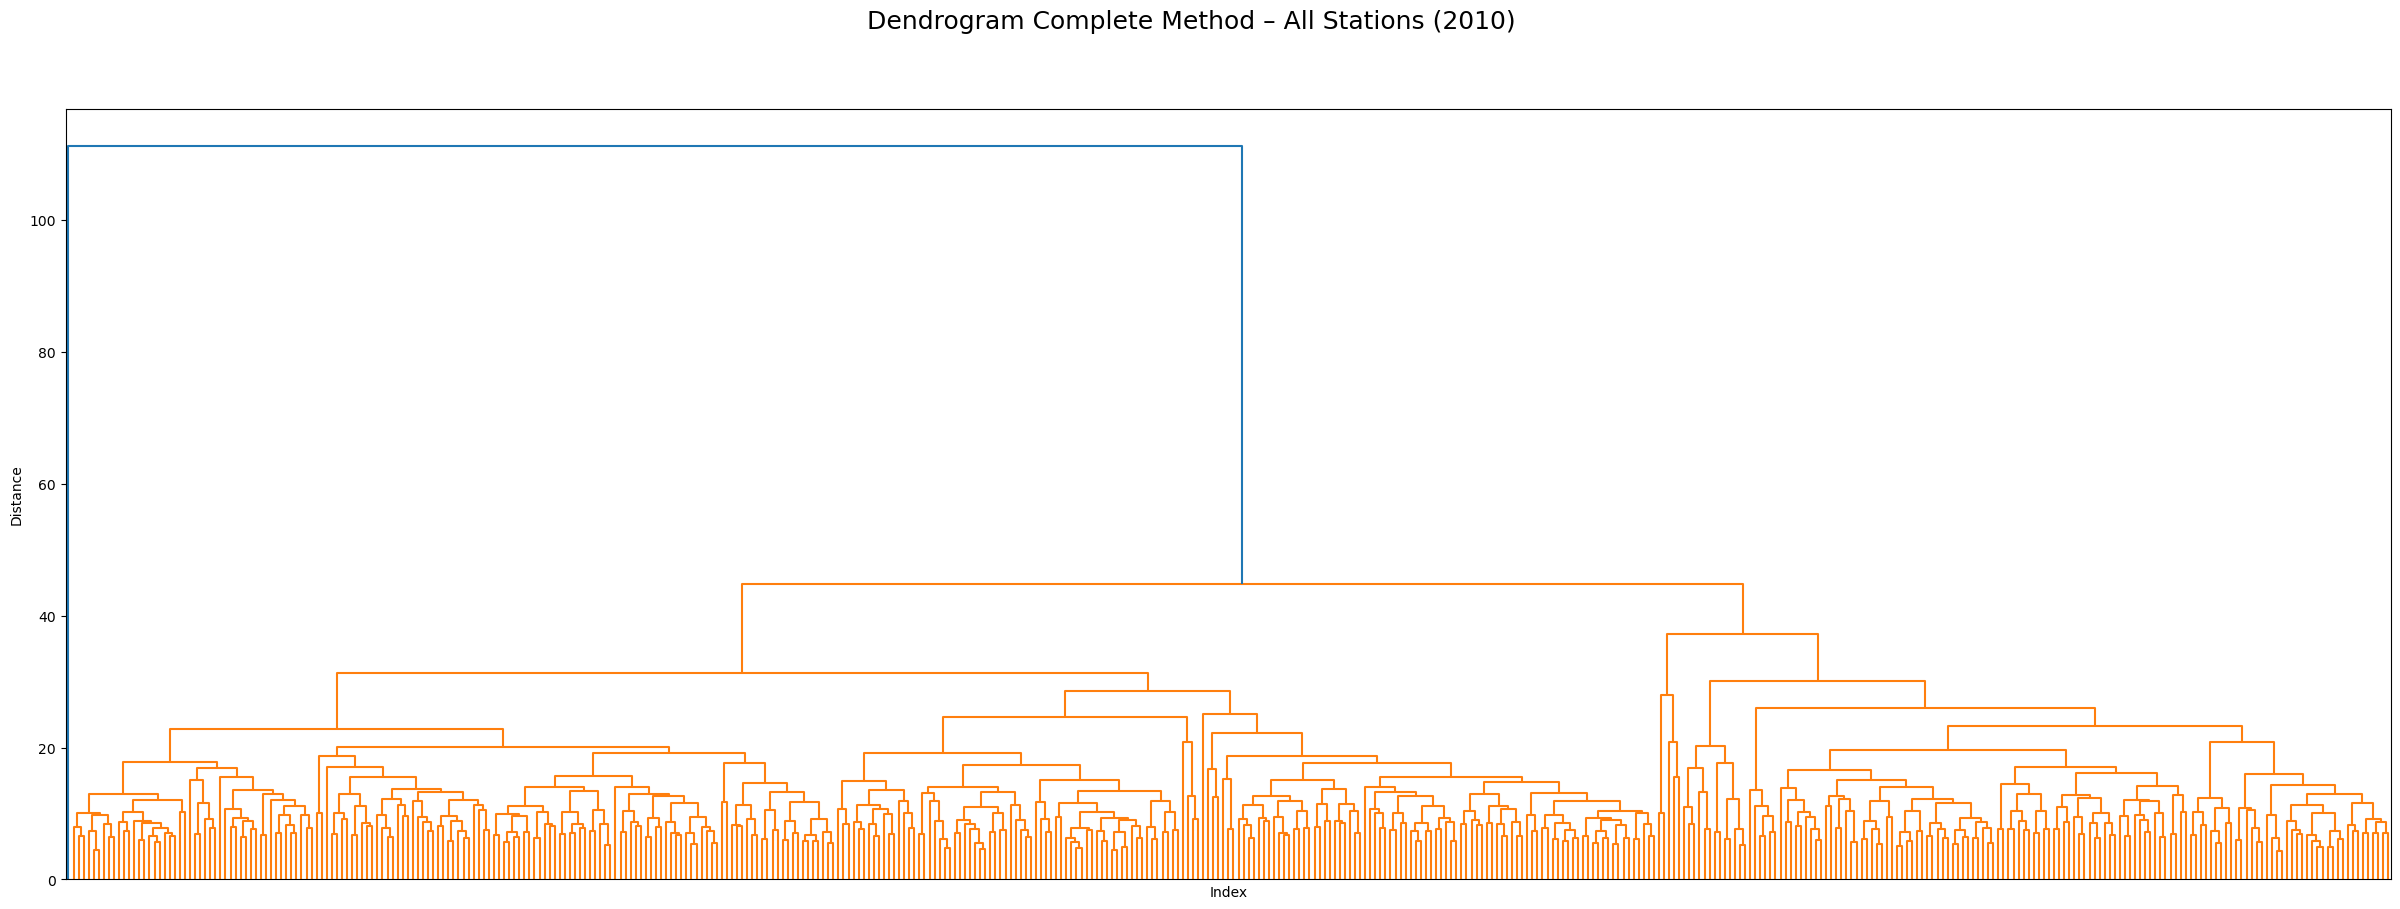

In [25]:
# Complete method for all cities

distance_complete_all = linkage(
    df2010.loc[:, feature_cols_all],
    method="complete"
)

plt.figure(figsize=(30, 10))
dendrogram(distance_complete_all, leaf_rotation=90, no_labels=True)
plt.xlabel("Index")
plt.ylabel("Distance")
plt.suptitle("Dendrogram Complete Method – All Stations (2010)", fontsize=18)
# Export plot
save_path = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/complete_dendro_all_cities.png"
plt.savefig(save_path, dpi=300)
plt.show()


**Complete Method Dendrogram – All Stations, 2010**

The complete method dendrogram reveals a clear macro-level separation with two dominant clusters merging only at a high linkage distance. Compared to single linkage, complete linkage produces more compact and balanced clusters, with much better interpretability. The structure suggests that daily weather observations across all stations group into a small number of broad climatic regimes, with meaningful substructure within each regime.

# 4.3 Average method for all cities

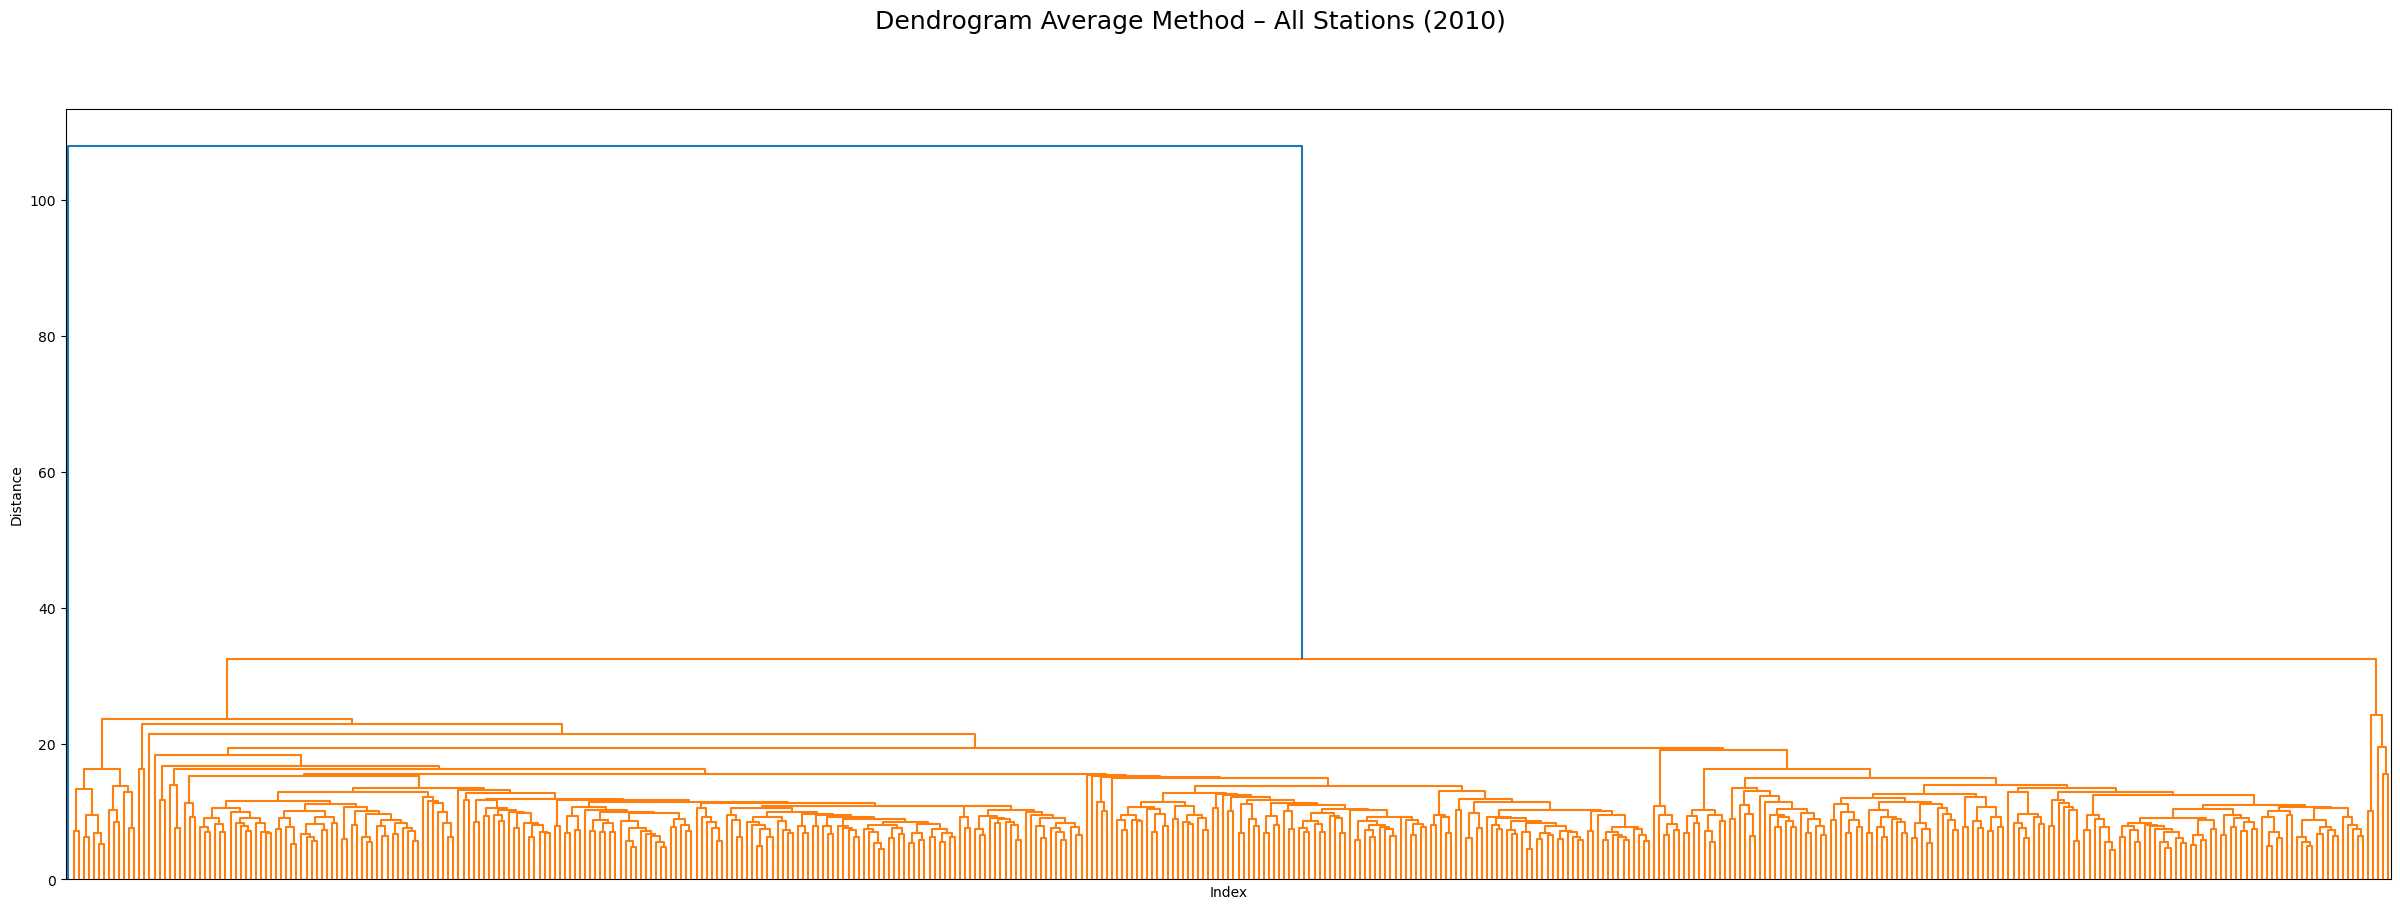

In [26]:
distance_average_all = linkage(
    df2010.loc[:, feature_cols_all],
    method="average"
)

plt.figure(figsize=(30, 10))
dendrogram(distance_average_all, leaf_rotation=90, no_labels=True)
plt.xlabel("Index")
plt.ylabel("Distance")
plt.suptitle("Dendrogram Average Method – All Stations (2010)", fontsize=18)
# Export plot
save_path = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/average_dendro_all_cities.png"
plt.savefig(save_path, dpi=300)
plt.show()

**Average Method Dendrogram – All Stations, 2010**

The average-method dendrogram shows a clear high-level separation of daily weather observations across all stations, with two dominant clusters merging only at a high linkage distance. Compared to complete linkage, cluster merging occurs more gradually with smoother transitions between weather regimes. This pattern suggests that average linkage captures broad climatic groupings while preserving overlap among transitional conditions, which may be more useful for exploratory analysis of weather similarity across stations.

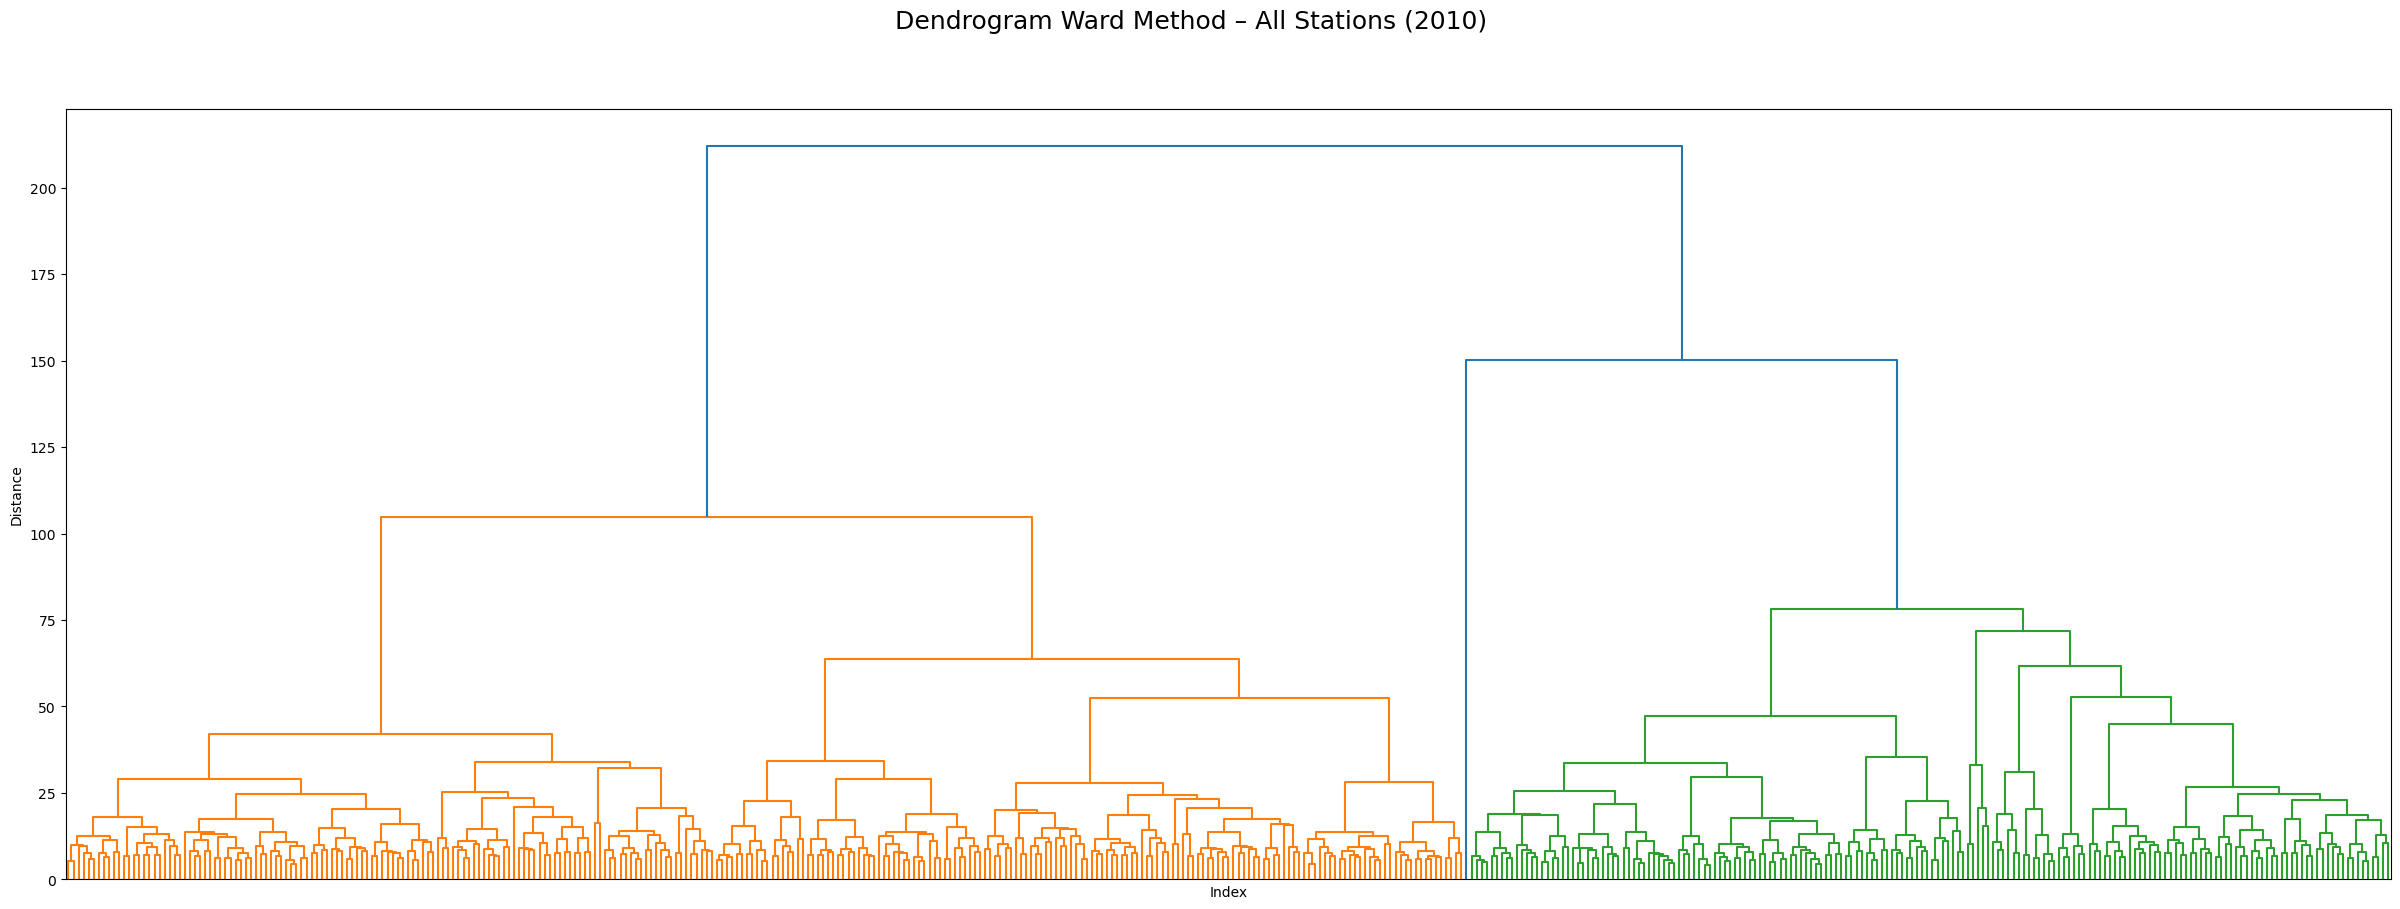

In [27]:
# 4.4 Ward method for all cities
distance_ward_all = linkage(
    df2010.loc[:, feature_cols_all],
    method="ward"
)

plt.figure(figsize=(30, 10))
dendrogram(distance_ward_all, leaf_rotation=90, no_labels=True)
plt.xlabel("Index")
plt.ylabel("Distance")
plt.suptitle("Dendrogram Ward Method – All Stations (2010)", fontsize=18)
# Export plot
save_path = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations/ward_dendro_all_cities.png"
plt.savefig(save_path, dpi=300)
plt.show()

**Ward Method Dendrogram – All Stations, 2010**

The Ward-method dendrogram reveals the strongest and most interpretable cluster structure among all linkage methods. A very large increase in linkage distance at the final merge indicates that daily weather observations across all stations naturally divide into two highly distinct macro-clusters. Within each cluster, the hierarchical structure is compact and well balanced. This shows Ward’s objective of minimizing within-cluster variance. This result suggests that Ward linkage is the most suitable method for identifying meaningful weather regimes in the ClimateWins dataset and provides a strong foundation for downstream PCA-based validation and comparison with “pleasant weather” labels.